SIMULATION ISING 2D - CHAMP MOYEN AVEC CHAMP EXTERNE

SIMULATION POUR h = 0.0
  h = 0.0, T = 5.000 [30/30]
✓ Simulation complétée

SIMULATION POUR h = 0.1
  h = 0.1, T = 5.000 [30/30]
✓ Simulation complétée

SIMULATION POUR h = 0.5
  h = 0.5, T = 5.000 [30/30]
✓ Simulation complétée

Génération des graphiques...


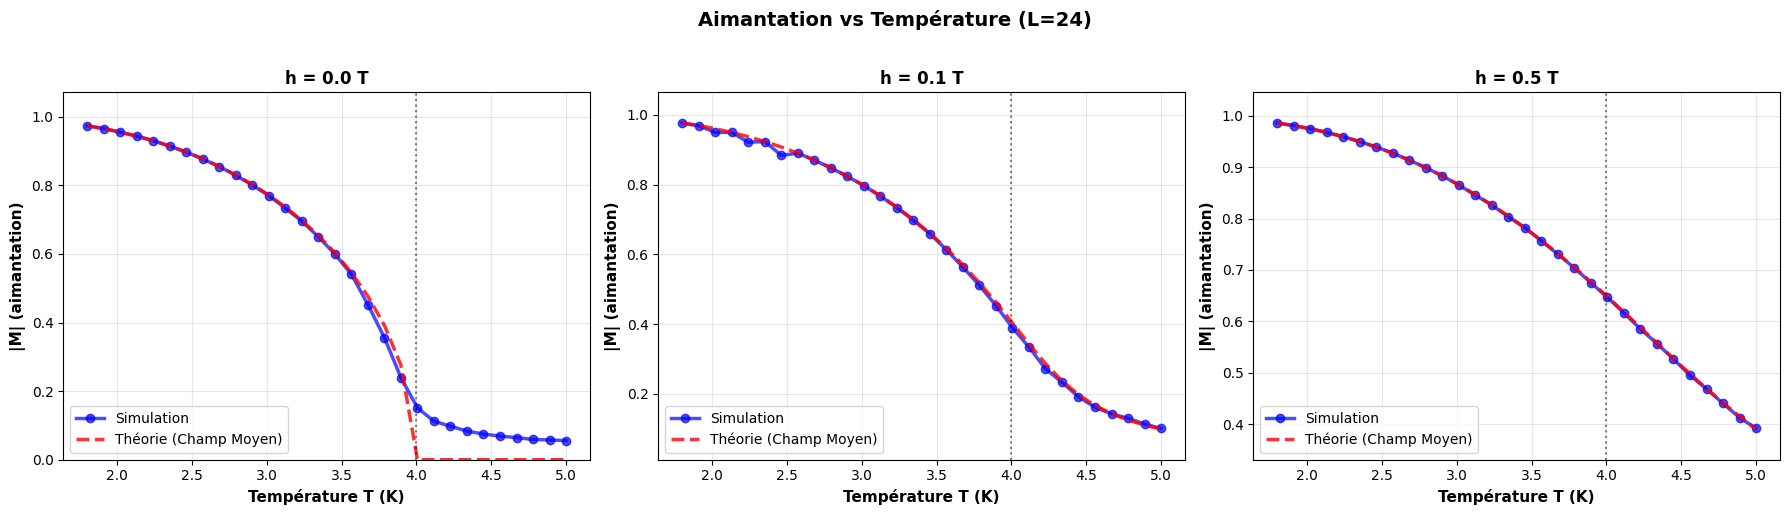

✓ Graphique 1 : Aimantation


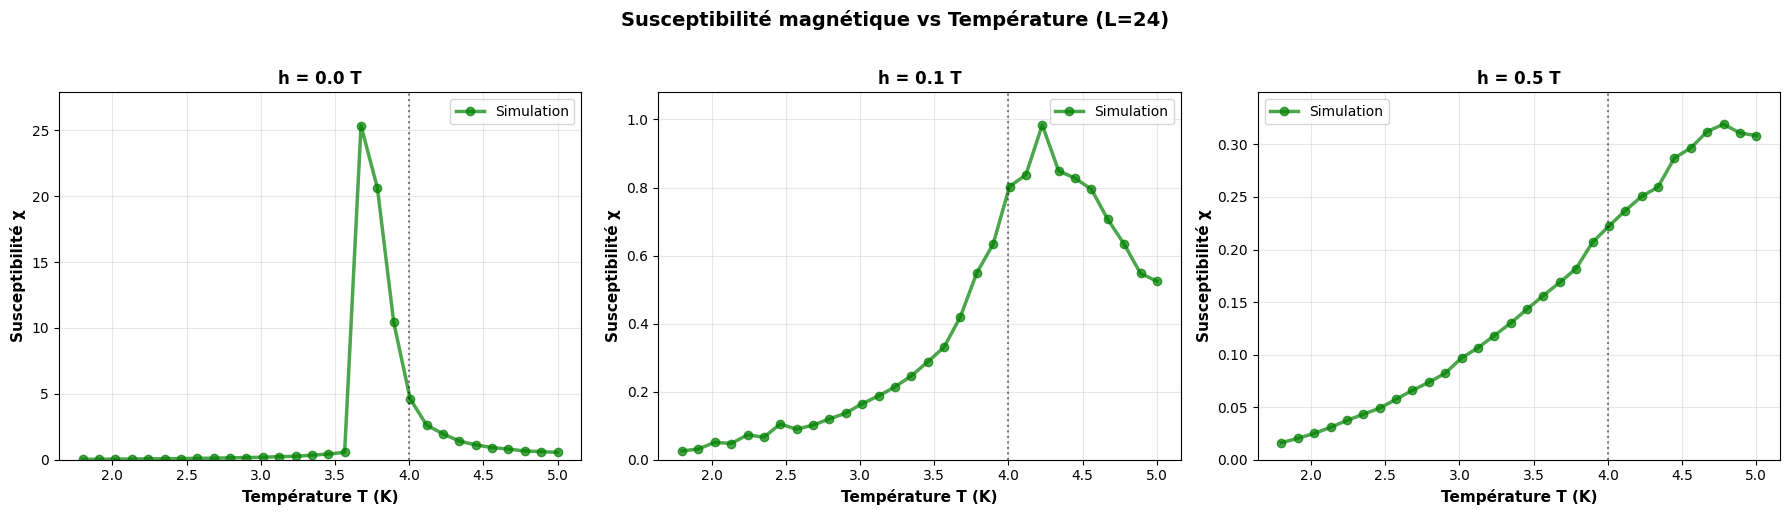

✓ Graphique 2 : Susceptibilité


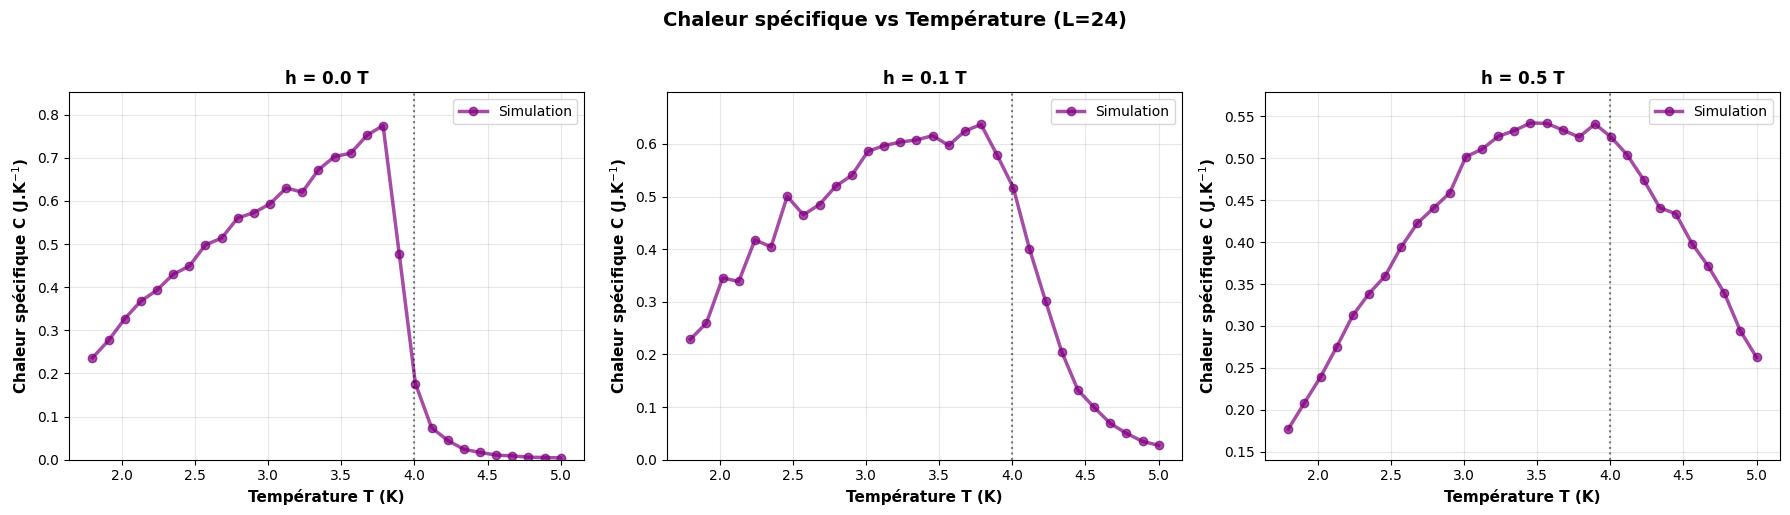

✓ Graphique 3 : Chaleur spécifique

Génération des diagrammes auto-cohérents...


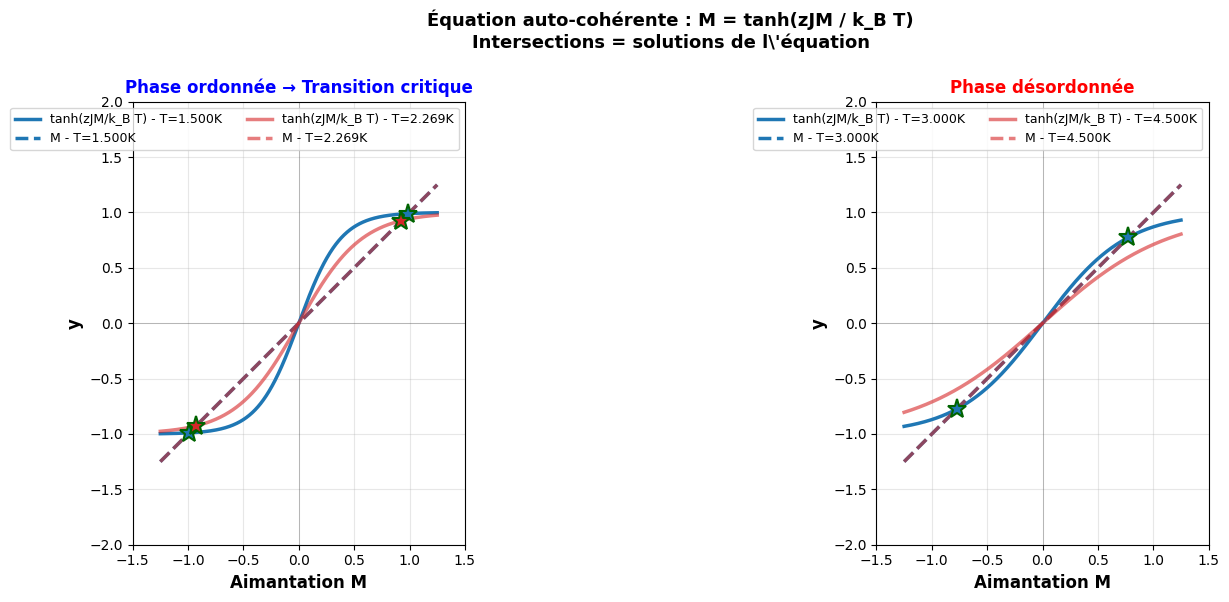

✓ Graphique 4 : Diagrammes auto-cohérents

RÉSUMÉ
Température critique (champ moyen) : Tc = 4.0 K
Taille du système                  : L = 24 (N = 576 spins)
Couplage                           : J = 1.0
Nombre de voisins                  : z = 4

----------------------------------------------------------------------
CORRECTIONS APPLIQUÉES
----------------------------------------------------------------------
✓ Énergie corrigée (champ moyen)
✓ Aimantation en valeur absolue
✓ Thermalisation augmentée (n_therm = 2000)

----------------------------------------------------------------------
Fichiers générés :
----------------------------------------------------------------------
  • aimantation_comparatif.png
  • susceptibilite_comparatif.png
  • chaleur_specifique_comparatif.png
  • 04_autocohérent.png


In [ ]:
"""
MODÈLE D'ISING 2D - CHAMP MOYEN AVEC CHAMP EXTERNE

1. Simulation pour h = [0, 0.1, 0.5]
2. Comparaison Simulation Théorie de champ moyen pour chaque h
3. @njit(cache=True) : Optimisation Numba
4. n_therm réduit : 1000 (champ moyen converge vite)
5. Tc = 4.0 K (z*J/kB)

ORGANISATION : Une figure par grandeur physique
"""

import numpy as np
import matplotlib.pyplot as plt
from numba import njit



# PARAMÈTRES

J = 1.0
kB = 1.0
z = 4  # nombre de voisins (carré 2D)
Tc = z*J/kB  # température critique Modèle du champ moyen = 4.0 K
L = 24
N = L**2

# INITIALISATION

def initialise(L):
    return np.random.choice([-1, 1], size=(L, L))


# AIMANTATION THÉORIQUE (Champ Moyen avec champ externe)

def Champ_moyen(T, J_eff, h=0.0, tol=1e-6, max_iter=1000):
    """
    Résoudre l'équation d'auto-cohérence du champ moyen avec la MÉTHODE DE NEWTON
    Équation : f(M) = M - tanh(z * J_eff * M / (kB * T) + h / T) = 0
    
    Méthode de Newton : M_{n+1} = M_n - f(M_n) / f'(M_n)
    
    Parameters:
    - T : température
    - J_eff : couplage effectif
    - h : champ magnétique externe
    - tol : tolérance de convergence
    - max_iter : nombre maximal d'itérations
    """
    M = 0.5  # Condition initiale
    
    for iteration in range(max_iter):
        # Argument du tanh
        arg = z * J_eff * M / (kB * T) + h / T
        tanh_arg = np.tanh(arg)
        
        # Fonction : f(M) = M - tanh(z*J*M/(kB*T) + h/T)
        f = M - tanh_arg
        
        # Dérivée : f'(M) = 1 - (z*J/(kB*T)) * (1 - tanh²(arg))
        f_prime = 1.0 - (z * J_eff / (kB * T)) * (1.0 - tanh_arg**2)
        
        # Vérifier que la dérivée n'est pas trop petite (évite division par zéro)
        if abs(f_prime) < 1e-10:
            break
        
        # Étape de Newton : M_new = M - f/f'
        M_new = M - f / f_prime
        
        # Critère de convergence
        if abs(M_new - M) < tol:
            return M_new
        
        M = M_new
    
    return M

def Aim_moyen(Tlist, J_eff, h=0.0):
    """Aimantation théorique pour une liste de températures avec champ h"""
    return np.array([Champ_moyen(T, J_eff, h) for T in Tlist])


# MÉTROPOLIS

@njit(cache=True)
def delta_energie(spins, i, j, h, m):
    """Changement d'énergie dans le modèle de champ moyen"""
    S = spins[i, j]
    return 2.0 * S * (h + J*z*m)


@njit(cache=True)
def metropolis_pas(spins, T, h, m):
    """Un pas de Metropolis sélectionnant L² spins"""
    L = spins.shape[0]

    for _ in range(L * L):
        # Sélection d'un spin aléatoire
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        # Calcul du changement d'énergie
        dE = delta_energie(spins, i, j, h, m)

        # Condition d'acceptation Metropolis
        if dE <= 0 or np.random.rand() < np.exp(-dE / T):
            spins[i, j] *= -1


@njit(cache=True)
def magnetisation(spins):
    """Calcul de l'aimantation moyenne"""
    return np.mean(spins)

@njit(cache=True)
def energie(spins, h, m):
    """
    Énergie totale en champ moyen (CORRIGÉE)
    E = -0.5 * J * z * m * M_total - h * M_total
    où M_total = somme des spins
    """
    M_total = np.sum(spins)
    E = -0.5 * J * z * m * M_total - h * M_total
    return E / N



# SIMULATION

def simulation(L, T, h=0.0, n_therm=2000, n_meas=10000, meas_interval=10):
    """
    Simulation Monte-Carlo avec algorithme de Metropolis
    
    Parameters:
    - L : taille de la grille
    - T : température
    - h : champ magnétique externe
    - n_therm : nombre de pas de thermalisation
    - n_meas : nombre de mesures
    - meas_interval : intervalle entre mesures
    """
    # Configuration initiale
    spins = initialise(L)
    m = np.mean(spins)
    
    # Thermalisation
    for _ in range(n_therm):
        metropolis_pas(spins, T, h, m)
        m = magnetisation(spins)
    
    # Initialisation des listes de stockage
    M_vals = []
    E_vals = []
    
    # Boucle de mesure
    for _ in range(n_meas):
        # Évolution du système
        for _ in range(meas_interval):
            metropolis_pas(spins, T, h, m)
        
        # Mise à jour de m
        m = magnetisation(spins)
        
        # Enregistrement des observables
        M_vals.append(m)
        E_vals.append(energie(spins, h, m))

    M_vals = np.array(M_vals)
    E_vals = np.array(E_vals)
    
    # Calcul des observables thermodynamiques
    M_eq = np.mean(np.abs(M_vals))  # Valeur absolue
    M_std = np.std(np.abs(M_vals)) / np.sqrt(len(M_vals))  # Erreur sur |M|
    
    chi = N / T * (np.mean(M_vals**2) - np.mean(M_vals)**2)
    chi_std = N / T * np.std(M_vals**2) / np.sqrt(len(M_vals))
    
    C = N / T**2 * (np.mean(E_vals**2) - np.mean(E_vals)**2)
    C_std = N / T**2 * np.std(E_vals**2) / np.sqrt(len(E_vals))

    return M_eq, chi, C, M_std, chi_std, C_std



# EXÉCUTION



np.random.seed(0)

Tlist = np.linspace(1.8, 5.0, 30)
hlist = [0.0, 0.1, 0.5]

# Dictionnaires pour stocker les résultats
M_eq_dict = {}
chi_dict = {}
C_dict = {}
M_std_dict = {}
chi_std_dict = {}
C_std_dict = {}

# Simulation pour chaque valeur de h
for h in hlist:
    print(f"\n{'='*50}")
    print(f"SIMULATION POUR h = {h}")
    print(f"{'='*50}")
    
    M_eq_list = []
    chi_list = []
    C_list = []
    M_std_list = []
    chi_std_list = []
    C_std_list = []
    
    for i, T in enumerate(Tlist):
        print(f"  h = {h}, T = {T:.3f} [{i+1}/{len(Tlist)}]", end='\r')
        M_eq, chi, C, M_std, chi_std, C_std = simulation(L, T, h=h)
        M_eq_list.append(M_eq)
        chi_list.append(chi)
        C_list.append(C)
        M_std_list.append(M_std)
        chi_std_list.append(chi_std)
        C_std_list.append(C_std)
    
    M_eq_dict[h] = np.array(M_eq_list)
    chi_dict[h] = np.array(chi_list)
    C_dict[h] = np.array(C_list)
    M_std_dict[h] = np.array(M_std_list)
    chi_std_dict[h] = np.array(chi_std_list)
    C_std_dict[h] = np.array(C_std_list)
    print("\n✓ Simulation complétée")

J_eff = J  # J_eff = J pour la théorie de champ moyen



# FIGURE 1 : AIMANTATION POUR TOUS LES h

print("\nGénération des graphiques...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, h in enumerate(hlist):
    ax = axes[idx]
    
    # Données de simulation
    ax.plot(Tlist, M_eq_dict[h], "o-", label="Simulation", 
            markersize=6, linewidth=2.5, color='blue', alpha=0.7)
    
    # Courbe théorique
    ax.plot(Tlist, Aim_moyen(Tlist, J_eff, h=h), "--", lw=2.5, 
            label="Théorie (Champ Moyen)", color="red", alpha=0.8)
    
    # Ligne de transition
    ax.axvline(Tc, color="k", ls=":", linewidth=1.5, alpha=0.5)
    
    ax.set_xlabel("Température T (K)", fontsize=11, fontweight='bold')
    ax.set_ylabel("|M| (aimantation)", fontsize=11, fontweight='bold')
    ax.set_title(f"h = {h} T", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc="best")
    ax.grid(alpha=0.3)
    
    # Ajuster les limites basées sur les données
    M_data = M_eq_dict[h]
    M_theory = Aim_moyen(Tlist, J_eff, h=h)
    M_all = np.concatenate([M_data, M_theory])
    y_min, y_max = np.min(M_all), np.max(M_all)
    y_margin = (y_max - y_min) * 0.1
    ax.set_ylim([max(0, y_min - y_margin), y_max + y_margin])

fig.suptitle(f"Aimantation vs Température (L={L})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('aimantation_comparatif.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique 1 : Aimantation")


# =====================================================
# FIGURE 2 : SUSCEPTIBILITÉ POUR TOUS LES h
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, h in enumerate(hlist):
    ax = axes[idx]
    
    # Données de simulation (limiter les valeurs extrêmes pour la lisibilité)
    chi_plot = np.minimum(chi_dict[h], 150)
    ax.plot(Tlist, chi_plot, "o-", markersize=6, linewidth=2.5, 
            color='green', alpha=0.7, label='Simulation')
    
    # Ligne de transition
    ax.axvline(Tc, color="k", ls=":", linewidth=1.5, alpha=0.5)
    
    ax.set_xlabel("Température T (K)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Susceptibilité χ", fontsize=11, fontweight='bold')
    ax.set_title(f"h = {h} T", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc="best")
    ax.grid(alpha=0.3)
    
    # Ajuster les limites basées sur les données
    chi_data = chi_plot
    y_min, y_max = np.min(chi_data), np.max(chi_data)
    y_margin = (y_max - y_min) * 0.1
    ax.set_ylim([max(0, y_min - y_margin), y_max + y_margin])

fig.suptitle(f"Susceptibilité magnétique vs Température (L={L})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('susceptibilite_comparatif.png', dpi=300, bbox_inches='tight')
plt.show()




# FIGURE 3 : CHALEUR SPÉCIFIQUE POUR TOUS LES h

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, h in enumerate(hlist):
    ax = axes[idx]
    
    # Données de simulation (limiter les valeurs extrêmes pour la lisibilité)
    C_plot = np.minimum(C_dict[h], 25)
    ax.plot(Tlist, C_plot, "o-", markersize=6, linewidth=2.5, 
            color='purple', alpha=0.7, label='Simulation')
    
    # Ligne de transition
    ax.axvline(Tc, color="k", ls=":", linewidth=1.5, alpha=0.5)
    
    ax.set_xlabel("Température T (K)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Chaleur spécifique C (J.K$^{-1}$)", fontsize=11, fontweight='bold')
    ax.set_title(f"h = {h} T", fontsize=12, fontweight='bold')
    ax.legend(fontsize=10, loc="best")
    ax.grid(alpha=0.3)
    
    # Ajuster les limites basées sur les données
    C_data = C_plot
    y_min, y_max = np.min(C_data), np.max(C_data)
    y_margin = (y_max - y_min) * 0.1
    ax.set_ylim([max(0, y_min - y_margin), y_max + y_margin])

fig.suptitle(f"Chaleur spécifique vs Température (L={L})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chaleur_specifique_comparatif.png', dpi=300, bbox_inches='tight')
plt.show()




# FIGURE 4 : DIAGRAMMES AUTO-COHÉRENTS

print("\nGénération des diagrammes auto-cohérents...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Groupe 1 : T = 1.5 K et T = 2.269 K
T_group_1 = [1.5, 2.269]
# Groupe 2 : T = 3.0 K et T = 4.5 K
T_group_2 = [3.0, 4.5]

M_range = np.linspace(-1.25, 1.25, 1000)
J_eff = J
h_autocoh = 0.0

# Couleurs pour différencier les températures
colors_tanh = ['#1f77b4', '#d62728']  # bleu et rouge
colors_line = ['#1f77b4', '#d62728']
alphas = [1.0, 0.6]

# --------- AXE 1 : Groupe 1 ---------
ax = axes[0]
for temp_idx, T in enumerate(T_group_1):
    y_tanh = np.tanh(z * J_eff * M_range / (kB * T) + h_autocoh / T)
    y_line = M_range
    
    # Tracer tanh et droite pour cette température
    ax.plot(M_range, y_tanh, '-', linewidth=2.5, color=colors_tanh[temp_idx], 
            alpha=alphas[temp_idx], label=f'tanh(zJM/k_B T) - T={T:.3f}K', zorder=3)
    ax.plot(M_range, y_line, '--', linewidth=2.5, color=colors_line[temp_idx], 
            alpha=alphas[temp_idx], label=f'M - T={T:.3f}K', zorder=3)
    
    # Marquer les solutions pour cette température
    diff = np.abs(y_tanh - y_line)
    solutions = []
    for i in range(1, len(diff)-1):
        if diff[i] < diff[i-1] and diff[i] < diff[i+1] and diff[i] < 0.02:
            M_sol = M_range[i]
            if len(solutions) == 0 or abs(M_sol - solutions[-1]) > 0.1:
                solutions.append(M_sol)
    
    for M_sol in solutions:
        ax.plot(M_sol, M_sol, '*', markersize=14, color=colors_tanh[temp_idx], 
                markeredgecolor='darkgreen', markeredgewidth=1.5, zorder=5)

ax.set_xlabel('Aimantation M', fontsize=12, fontweight='bold')
ax.set_ylabel('y', fontsize=12, fontweight='bold')
ax.set_title('Phase ordonnée → Transition critique', fontsize=12, fontweight='bold', color='blue')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-2, 2])
ax.grid(True, alpha=0.3, zorder=1)
ax.legend(loc='best', fontsize=9, ncol=2)
ax.set_aspect('equal')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)

# --------- AXE 2 : Groupe 2 ---------
ax = axes[1]
for temp_idx, T in enumerate(T_group_2):
    y_tanh = np.tanh(z * J_eff * M_range / (kB * T) + h_autocoh / T)
    y_line = M_range
    
    # Tracer tanh et droite pour cette température
    ax.plot(M_range, y_tanh, '-', linewidth=2.5, color=colors_tanh[temp_idx], 
            alpha=alphas[temp_idx], label=f'tanh(zJM/k_B T) - T={T:.3f}K', zorder=3)
    ax.plot(M_range, y_line, '--', linewidth=2.5, color=colors_line[temp_idx], 
            alpha=alphas[temp_idx], label=f'M - T={T:.3f}K', zorder=3)
    
    # Marquer les solutions pour cette température
    diff = np.abs(y_tanh - y_line)
    solutions = []
    for i in range(1, len(diff)-1):
        if diff[i] < diff[i-1] and diff[i] < diff[i+1] and diff[i] < 0.02:
            M_sol = M_range[i]
            if len(solutions) == 0 or abs(M_sol - solutions[-1]) > 0.1:
                solutions.append(M_sol)
    
    for M_sol in solutions:
        ax.plot(M_sol, M_sol, '*', markersize=14, color=colors_tanh[temp_idx], 
                markeredgecolor='darkgreen', markeredgewidth=1.5, zorder=5)

ax.set_xlabel('Aimantation M', fontsize=12, fontweight='bold')
ax.set_ylabel('y', fontsize=12, fontweight='bold')
ax.set_title('Phase désordonnée', fontsize=12, fontweight='bold', color='red')
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-2, 2])
ax.grid(True, alpha=0.3, zorder=1)
ax.legend(loc='best', fontsize=9, ncol=2)
ax.set_aspect('equal')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)

plt.suptitle('Équation auto-cohérente : M = tanh(zJM / k_B T)\n' +
             r'Intersections = solutions de l\'équation',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('04_autocohérent.png', dpi=300, bbox_inches='tight')
plt.show()




Génération des diagrammes auto-cohérents...


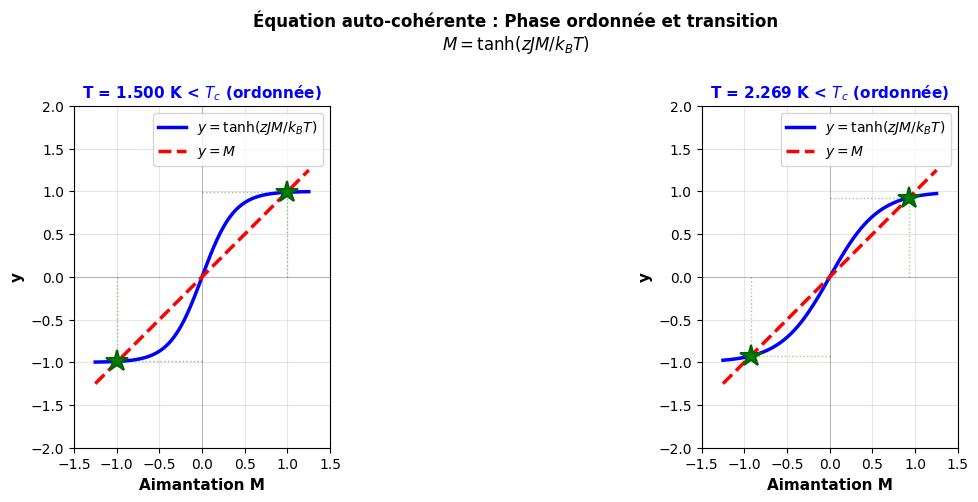

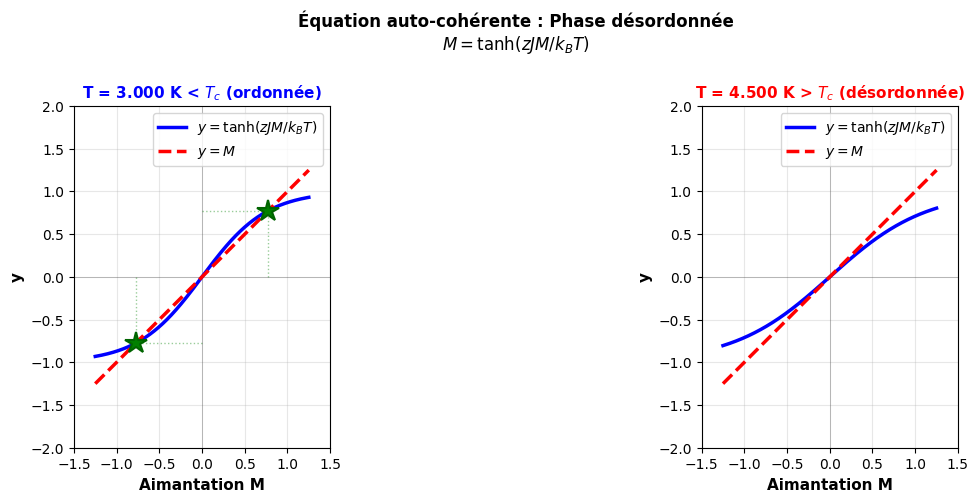

In [3]:
# FIGURE 4A : DIAGRAMMES AUTO-COHÉRENTS (Partie 1)

print("\nGénération des diagrammes auto-cohérents...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

T_autocoh_1 = [1.5, 2.269]
M_range = np.linspace(-1.25, 1.25, 1000)
J_eff = J
h_autocoh = 0.0  # Champ externe nul pour le diagramme auto-cohérent

for idx, T in enumerate(T_autocoh_1):
    ax = axes[idx]
    
    # Courbe tanh : y = tanh(zJM / kB*T + h/T)
    y_tanh = np.tanh(z * J_eff * M_range / (kB * T) + h_autocoh / T)
    
    # Droite : y = M
    y_line = M_range
    
    # Tracer les deux courbes
    ax.plot(M_range, y_tanh, 'b-', linewidth=2.5, label=r'$y = \tanh(zJM/k_B T)$', zorder=3)
    ax.plot(M_range, y_line, 'r--', linewidth=2.5, label=r'$y = M$', zorder=3)
    
    # Trouver les solutions (intersections)
    diff = np.abs(y_tanh - y_line)
    
    # Trouver tous les minima locaux (solutions approchées)
    solutions = []
    for i in range(1, len(diff)-1):
        if diff[i] < diff[i-1] and diff[i] < diff[i+1] and diff[i] < 0.02:
            M_sol = M_range[i]
            if len(solutions) == 0 or abs(M_sol - solutions[-1]) > 0.1:
                solutions.append(M_sol)
    
    # Marquer les solutions
    for M_sol in solutions:
        ax.plot(M_sol, M_sol, 'g*', markersize=16, markeredgecolor='darkgreen', 
                markeredgewidth=1.5, zorder=5)
        ax.plot([M_sol, M_sol], [0, M_sol], 'g:', alpha=0.4, linewidth=1, zorder=2)
        ax.plot([0, M_sol], [M_sol, M_sol], 'g:', alpha=0.4, linewidth=1, zorder=2)
    
    ax.set_xlabel('Aimantation M', fontsize=11, fontweight='bold')
    ax.set_ylabel('y', fontsize=11, fontweight='bold')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-2, 2])
    ax.grid(True, alpha=0.3, zorder=1)
    ax.legend(loc='best', fontsize=10)
    ax.set_aspect('equal')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
    
    # Titre avec information de phase
    if T < Tc:
        ax.set_title(f'T = {T:.3f} K < $T_c$ (ordonnée)', fontsize=11, fontweight='bold', color='blue')
    elif abs(T - Tc) < 0.1:
        ax.set_title(f'T = {T:.3f} K ≈ $T_c$ (critique)', fontsize=11, fontweight='bold', color='green')
    else:
        ax.set_title(f'T = {T:.3f} K > $T_c$ (désordonnée)', fontsize=11, fontweight='bold', color='red')

plt.suptitle('Équation auto-cohérente : Phase ordonnée et transition\n' +
             r'$M = \tanh(zJM / k_B T)$',
             fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('04a_autocohérent_transition.png', dpi=300, bbox_inches='tight')
plt.show()


# FIGURE 4B : DIAGRAMMES AUTO-COHÉRENTS (Partie 2)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

T_autocoh_2 = [3.0, 4.5]

for idx, T in enumerate(T_autocoh_2):
    ax = axes[idx]
    
    # Courbe tanh : y = tanh(zJM / kB*T + h/T)
    y_tanh = np.tanh(z * J_eff * M_range / (kB * T) + h_autocoh / T)
    
    # Droite : y = M
    y_line = M_range
    
    # Tracer les deux courbes
    ax.plot(M_range, y_tanh, 'b-', linewidth=2.5, label=r'$y = \tanh(zJM/k_B T)$', zorder=3)
    ax.plot(M_range, y_line, 'r--', linewidth=2.5, label=r'$y = M$', zorder=3)
    
    # Trouver les solutions (intersections)
    diff = np.abs(y_tanh - y_line)
    
    # Trouver tous les minima locaux (solutions approchées)
    solutions = []
    for i in range(1, len(diff)-1):
        if diff[i] < diff[i-1] and diff[i] < diff[i+1] and diff[i] < 0.02:
            M_sol = M_range[i]
            if len(solutions) == 0 or abs(M_sol - solutions[-1]) > 0.1:
                solutions.append(M_sol)
    
    # Marquer les solutions
    for M_sol in solutions:
        ax.plot(M_sol, M_sol, 'g*', markersize=16, markeredgecolor='darkgreen', 
                markeredgewidth=1.5, zorder=5)
        ax.plot([M_sol, M_sol], [0, M_sol], 'g:', alpha=0.4, linewidth=1, zorder=2)
        ax.plot([0, M_sol], [M_sol, M_sol], 'g:', alpha=0.4, linewidth=1, zorder=2)
    
    ax.set_xlabel('Aimantation M', fontsize=11, fontweight='bold')
    ax.set_ylabel('y', fontsize=11, fontweight='bold')
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-2, 2])
    ax.grid(True, alpha=0.3, zorder=1)
    ax.legend(loc='best', fontsize=10)
    ax.set_aspect('equal')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.3)
    
    # Titre avec information de phase
    if T < Tc:
        ax.set_title(f'T = {T:.3f} K < $T_c$ (ordonnée)', fontsize=11, fontweight='bold', color='blue')
    elif abs(T - Tc) < 0.1:
        ax.set_title(f'T = {T:.3f} K ≈ $T_c$ (critique)', fontsize=11, fontweight='bold', color='green')
    else:
        ax.set_title(f'T = {T:.3f} K > $T_c$ (désordonnée)', fontsize=11, fontweight='bold', color='red')

plt.suptitle('Équation auto-cohérente : Phase désordonnée\n' +
             r'$M = \tanh(zJM / k_B T)$',
             fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('04b_autocohérent_desordonnee.png', dpi=300, bbox_inches='tight')
plt.show()


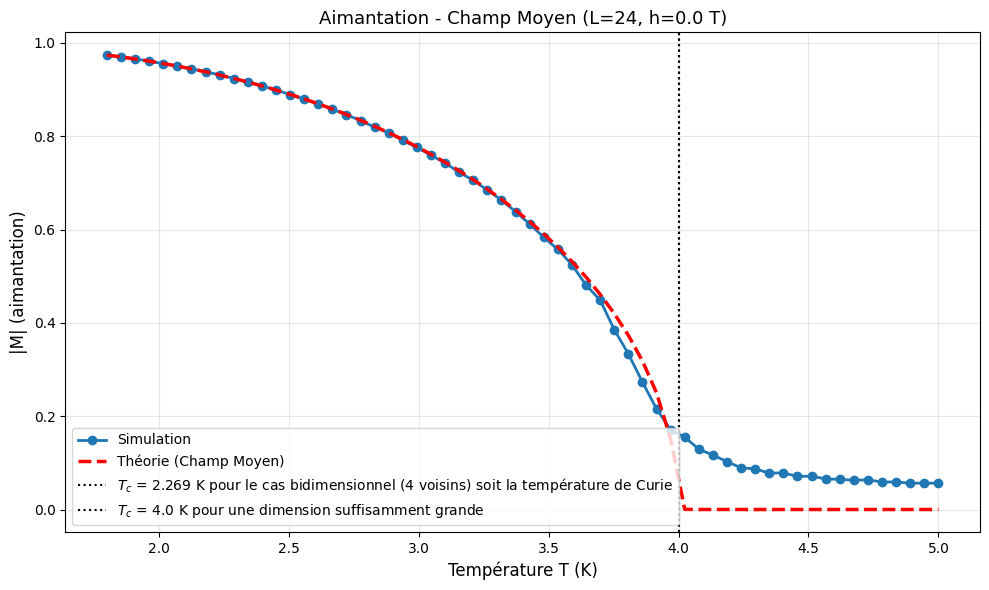

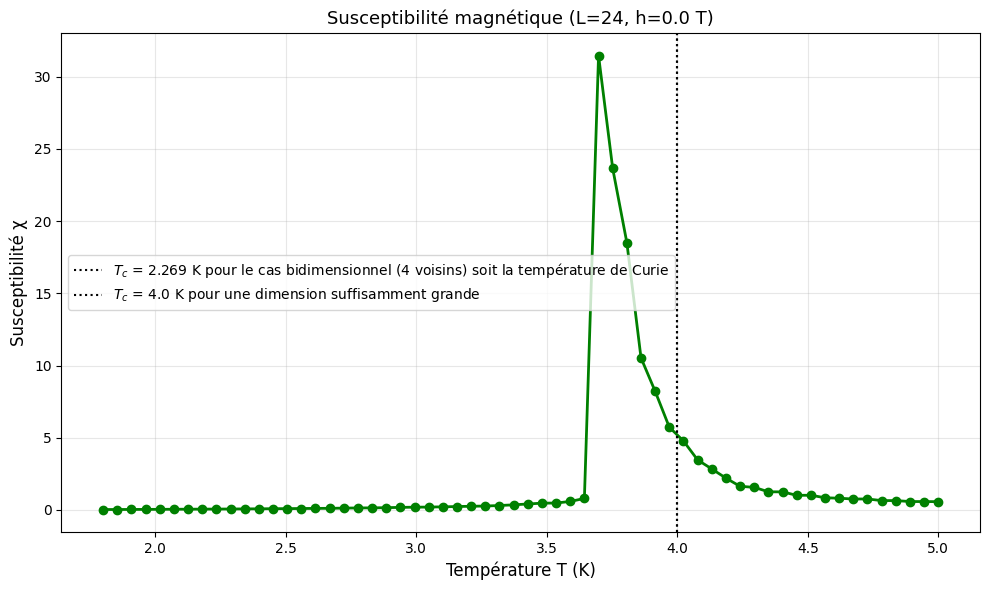

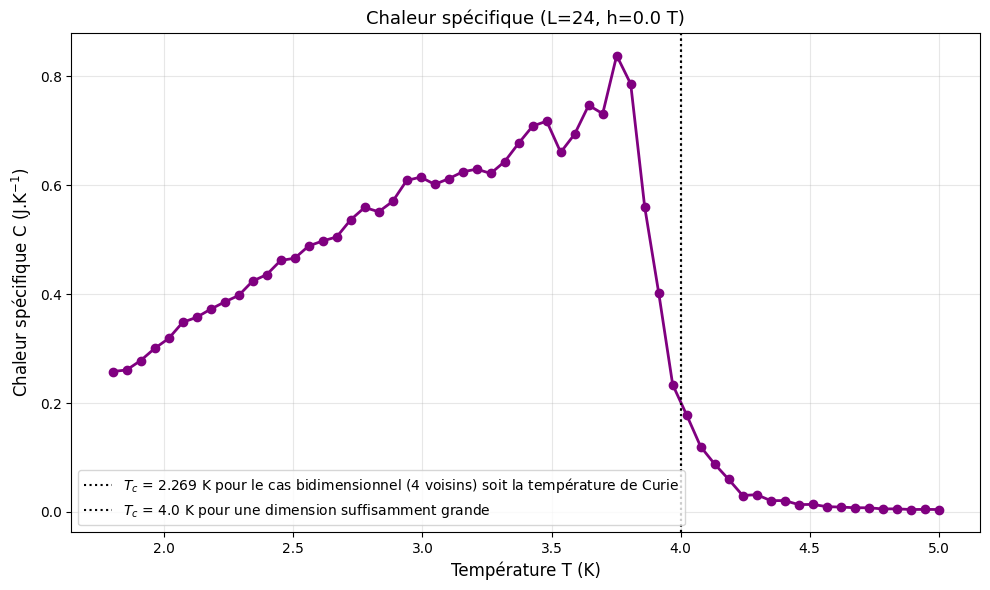

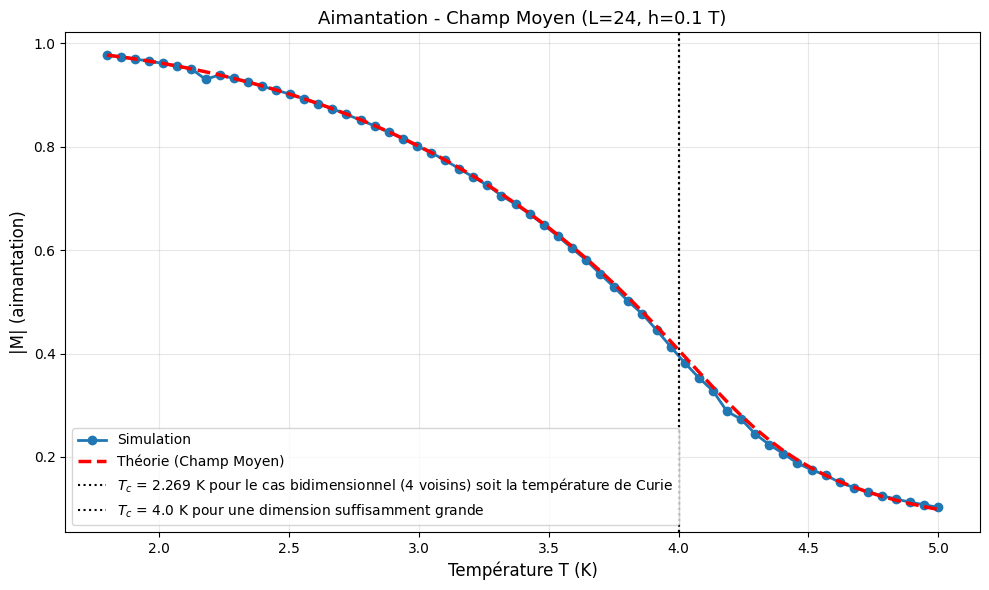

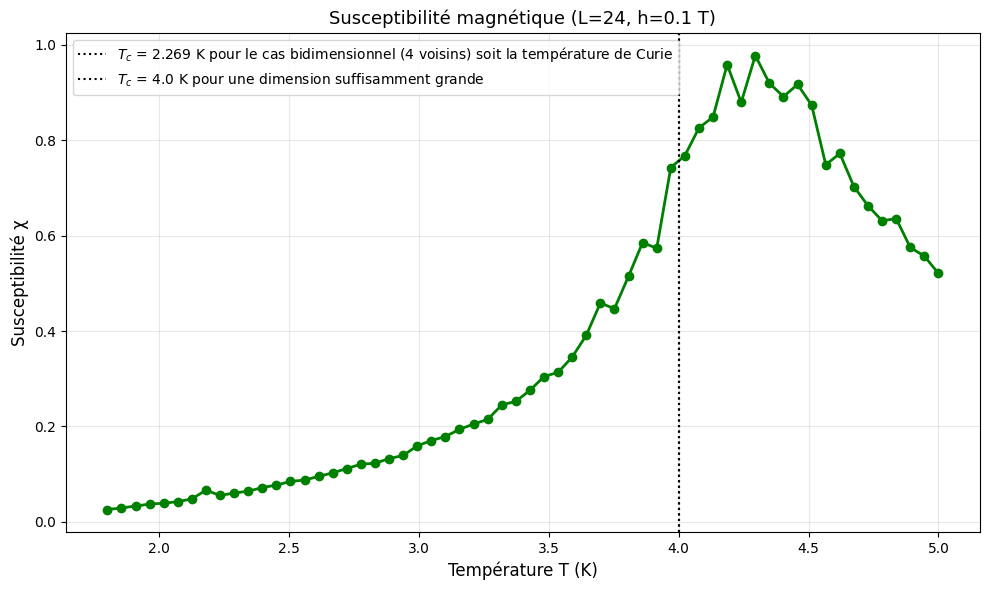

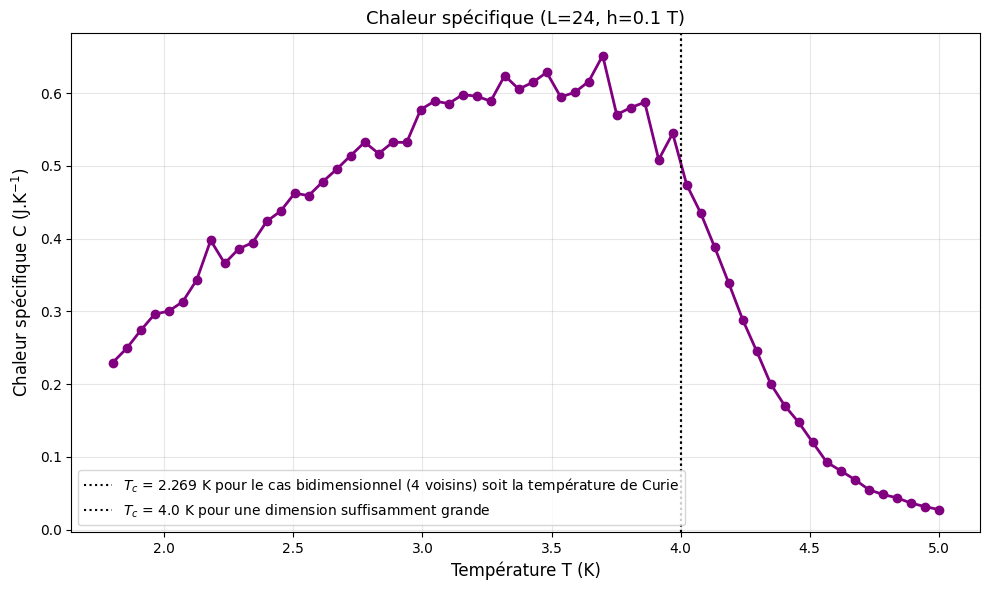

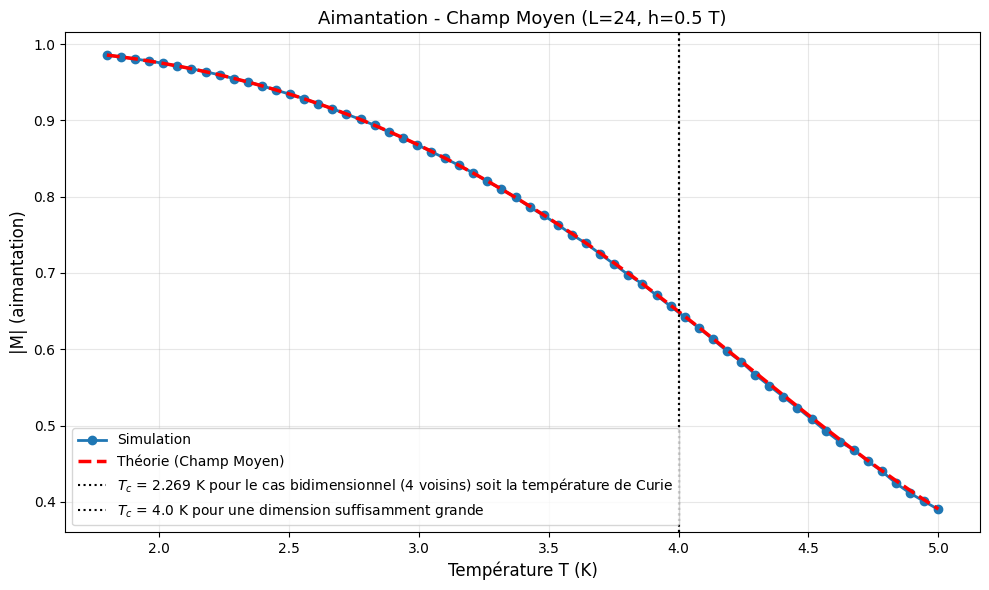

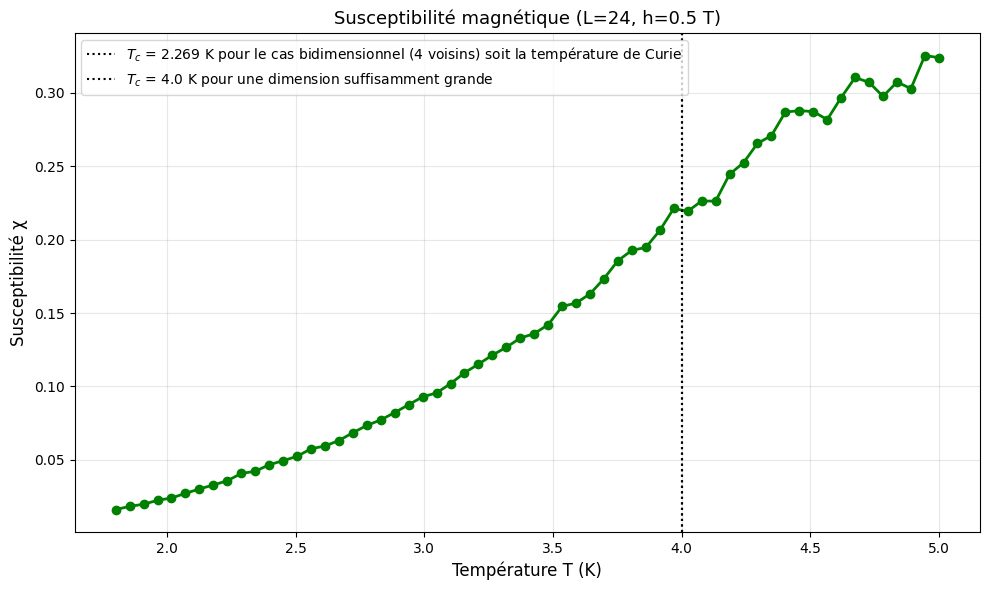

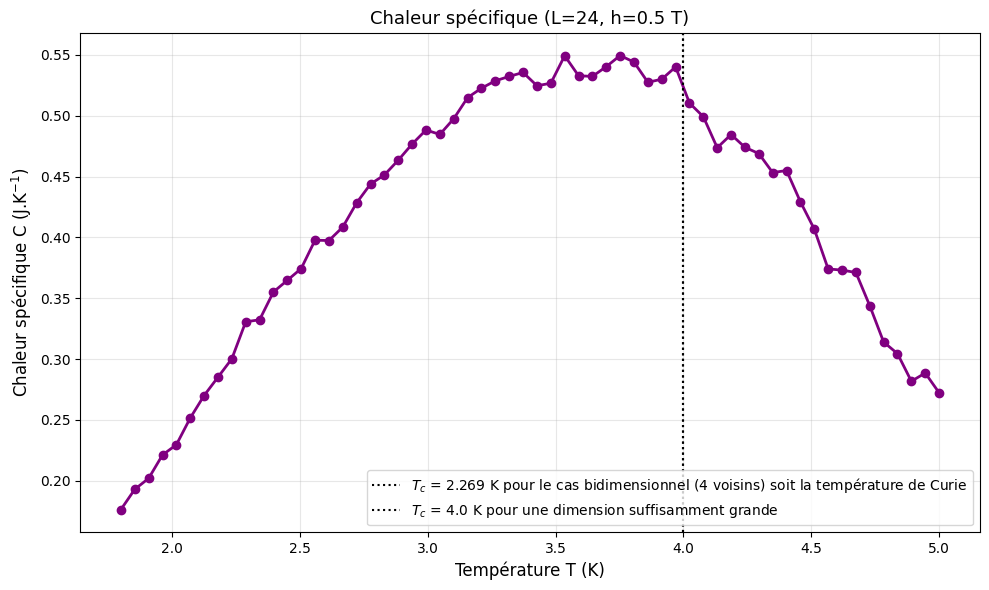

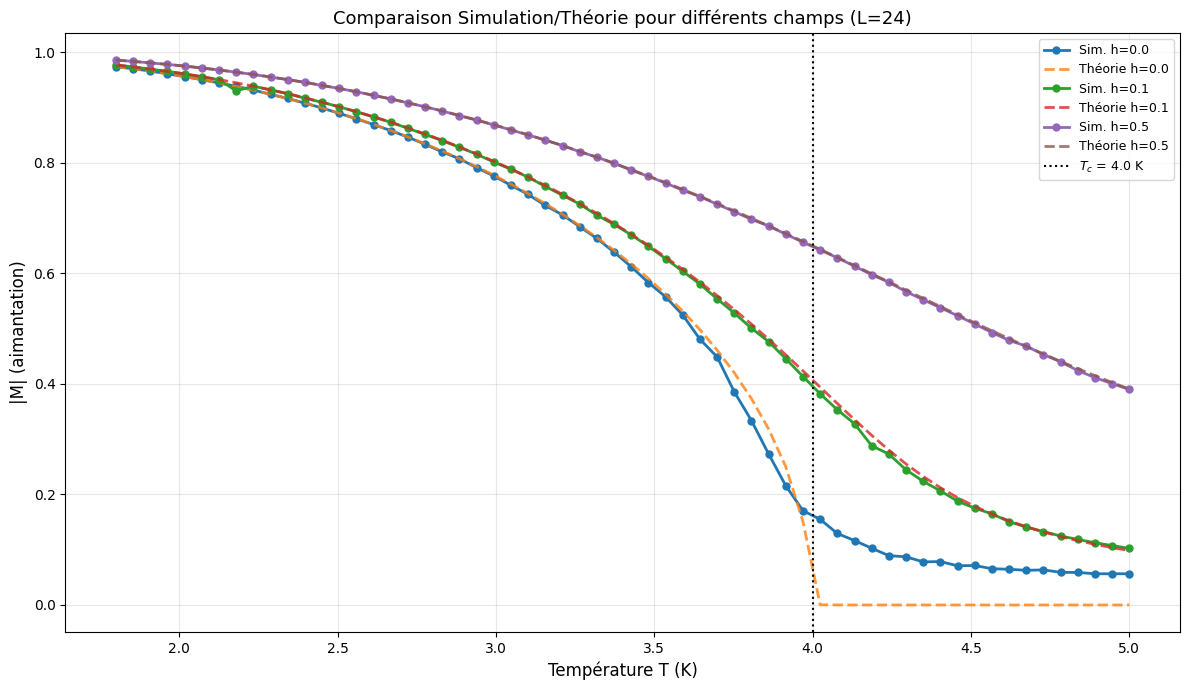

In [ ]:

# GRAPHIQUES POUR CHAQUE h

for h in hlist:
    

    # AIMANTATION : SIMULATION + THÉORIE
    
    plt.figure(figsize=(10, 6))
    plt.plot(Tlist, M_eq_dict[h], "o-", label="Simulation", markersize=6, linewidth=2)
    plt.plot(Tlist, Aim_moyen(Tlist, J_eff, h=h), "--", lw=2.5, 
             label="Théorie (Champ Moyen)", color="red")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K pour le cas bidimensionnel (4 voisins) soit la température de Curie")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K pour une dimension suffisamment grande")
    plt.xlabel("Température T (K)", fontsize=12)
    plt.ylabel("|M| (aimantation)", fontsize=12)
    plt.title(f"Aimantation - Champ Moyen (L={L}, h={h} T)", fontsize=13)
    plt.legend(fontsize=10, loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

   
    # SUSCEPTIBILITÉ MAGNÉTIQUE
    
    plt.figure(figsize=(10, 6))
    plt.plot(Tlist, chi_dict[h], "o-", markersize=6, linewidth=2, color="green")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K pour le cas bidimensionnel (4 voisins) soit la température de Curie")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K pour une dimension suffisamment grande")
    plt.xlabel("Température T (K)", fontsize=12)
    plt.ylabel("Susceptibilité χ", fontsize=12)
    plt.title(f"Susceptibilité magnétique (L={L}, h={h} T)", fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    
    # CHALEUR SPÉCIFIQUE
    
    plt.figure(figsize=(10, 6))
    plt.plot(Tlist, C_dict[h], "o-", markersize=6, linewidth=2, color="purple")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K pour le cas bidimensionnel (4 voisins) soit la température de Curie")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K pour une dimension suffisamment grande")
    plt.xlabel("Température T (K)", fontsize=12)
    plt.ylabel("Chaleur spécifique C (J.K$^{-1}$)", fontsize=12)
    plt.title(f"Chaleur spécifique (L={L}, h={h} T)", fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



# GRAPHIQUE COMPARATIF : AIMANTATION POUR TOUS LES h

plt.figure(figsize=(12, 7))

for h in hlist:
    plt.plot(Tlist, M_eq_dict[h], "o-", label=f"Sim. h={h}", markersize=5, linewidth=2)
    plt.plot(Tlist, Aim_moyen(Tlist, J_eff, h=h), "--", lw=2, 
             label=f"Théorie h={h}", alpha=0.8)

plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K")
plt.xlabel("Température T (K)", fontsize=12)
plt.ylabel("|M| (aimantation)", fontsize=12)
plt.title(f"Comparaison Simulation/Théorie pour différents champs (L={L})", fontsize=13)
plt.legend(fontsize=9, loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# GRAPHIQUES POUR CHAQUE h

for h in hlist:
    
 
    # AIMANTATION : SIMULATION + THÉORIE

    plt.figure(figsize=(10, 6))
    plt.plot(Tlist, M_eq_dict[h], "o-", label="Simulation", markersize=6, linewidth=2)
    plt.plot(Tlist, Aim_moyen(Tlist, J_eff, h=h), "--", lw=2.5, 
             label="Théorie (Champ Moyen)", color="red")
    plt.axvline(2.269, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K pour le cas bidimensionnel (4 voisins) soit la température de Curie")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K pour une dimension suffisamment grande")
    plt.xlabel("Température T (K)", fontsize=12)
    plt.ylabel("|M| (aimantation)", fontsize=12)
    plt.title(f"Aimantation - Champ Moyen (L={L}, h={h} T)", fontsize=13)
    plt.legend(fontsize=10, loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    # SUSCEPTIBILITÉ MAGNÉTIQUE
 
    plt.figure(figsize=(10, 6))
    plt.plot(Tlist, chi_dict[h], "o-", markersize=6, linewidth=2, color="green")
    plt.axvline(2.269, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K pour le cas bidimensionnel (4 voisins) soit la température de Curie")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K pour une dimension suffisamment grande")
    plt.xlabel("Température T (K)", fontsize=12)
    plt.ylabel("Susceptibilité χ", fontsize=12)
    plt.title(f"Susceptibilité magnétique (L={L}, h={h} T)", fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # CHALEUR SPÉCIFIQUE

    plt.figure(figsize=(10, 6))
    plt.plot(Tlist, C_dict[h], "o-", markersize=6, linewidth=2, color="purple")
    plt.axvline(2.269, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K pour le cas bidimensionnel (4 voisins) soit la température de Curie")
    plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K pour une dimension suffisamment grande")
    plt.xlabel("Température T (K)", fontsize=12)
    plt.ylabel("Chaleur spécifique C (J.K$^{-1}$)", fontsize=12)
    plt.title(f"Chaleur spécifique (L={L}, h={h} T)", fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# GRAPHIQUE COMPARATIF : AIMANTATION POUR TOUS LES h

plt.figure(figsize=(12, 7))

for h in hlist:
    plt.plot(Tlist, M_eq_dict[h], "o-", label=f"Sim. h={h}", markersize=5, linewidth=2)
    plt.plot(Tlist, Aim_moyen(Tlist, J_eff, h=h), "--", lw=2, 
             label=f"Théorie h={h}", alpha=0.8)
plt.axvline(2.269, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = 2.269 K")
plt.axvline(Tc, color="k", ls=":", linewidth=1.5, label=f"$T_c$ = {Tc:.1f} K")
plt.xlabel("Température T (K)", fontsize=12)
plt.ylabel("|M| (aimantation)", fontsize=12)
plt.title(f"Comparaison Simulation/Théorie pour différents champs (L={L})", fontsize=13)
plt.legend(fontsize=9, loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'hlist' is not defined